setup + glove

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/FakeNewsProject'

Mounted at /content/drive


In [ ]:
!pip install -q tensorflow mlflow

from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/FakeNewsProject'

# Télécharger GloVe 100d (822 MB)
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove/
!ls glove/

import numpy as np, pandas as pd

# Charger les splits
train = pd.read_csv(f'{BASE}/data/processed/train.csv')
val   = pd.read_csv(f'{BASE}/data/processed/val.csv')
test  = pd.read_csv(f'{BASE}/data/processed/test.csv')
print("✓ Données chargées")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 956.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

tokenisation + matrice glove

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN   = 400
VOCAB_SIZE = 60000
EMBED_DIM  = 100

tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tok.fit_on_texts(train['clean_text'].fillna(''))

def encode(df):
    seqs = tok.texts_to_sequences(df['clean_text'].fillna(''))
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = encode(train); y_train = train['label'].values
X_val   = encode(val);   y_val   = val['label'].values
X_test  = encode(test);  y_test  = test['label'].values

# Charger GloVe
print("Chargement GloVe...")
glove = {}
with open('glove/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        vals = line.split()
        glove[vals[0]] = np.array(vals[1:], dtype='float32')

# Matrice d'embedding
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
found = 0
for word, idx in tok.word_index.items():
    if idx < VOCAB_SIZE and word in glove:
        embed_matrix[idx] = glove[word]
        found += 1

print(f"✓ GloVe chargé — {found}/{min(VOCAB_SIZE, len(tok.word_index))} mots trouvés")

Chargement GloVe...
✓ GloVe chargé — 45230/60000 mots trouvés


architecture bilstm + attention custom

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class AttentionLayer(tf.keras.layers.Layer):
    """Mécanisme d'attention sur les sorties LSTM."""
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(1,), initializer='zeros', trainable=True)

    def call(self, x):
        score   = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

def build_bilstm():
    inp = layers.Input(shape=(MAX_LEN,))
    x   = layers.Embedding(VOCAB_SIZE, EMBED_DIM,
                            weights=[embed_matrix], trainable=False)(inp)
    x   = layers.SpatialDropout1D(0.3)(x)
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x   = layers.Bidirectional(layers.LSTM(64,  return_sequences=True))(x)
    x   = AttentionLayer()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='binary_crossentropy',
               metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    m.summary()
    return m

model_lstm = build_bilstm()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 400, 100)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 400, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 400, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 400, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           129 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,415,618 (24.47 MB)

 Trainable params: 415,618 (1.59 MB)

 Non-trainable params: 6,000,000 (22.89 MB)

entrainement + courbe learning

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 25s 119ms/step - accuracy: 0.9911 - auc: 0.9994 - loss: 0.0248 - val_accuracy: 0.9825 - val_auc: 0.9983 - val_loss: 0.0508 - learning_rate: 5.0000e-04
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.9914 - auc: 0.9994 - loss: 0.0251 - val_accuracy: 0.9911 - val_auc: 0.9989 - val_loss: 0.0257 - learning_rate: 5.0000e-04
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 26s 125ms/step - accuracy: 0.9924 - auc: 0.9995 - loss: 0.0219 - val_accuracy: 0.9906 - val_auc: 0.9989 - val_loss: 0.0296 - learning_rate: 5.0000e-04
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.9936 - auc: 0.9994 - loss: 0.0196 - val_accuracy: 0.9922 - val_auc: 0.9991 - val_loss: 0.0224 - learning_rate: 5.0000e-04
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 25s 116ms/step - accuracy: 0.9926 - auc: 0.9996 - loss: 0.0199 - val_accuracy: 0.9934 - val_auc: 0.9992 - val_loss: 0.0209 - learning_rate: 5.0000e-04
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 1

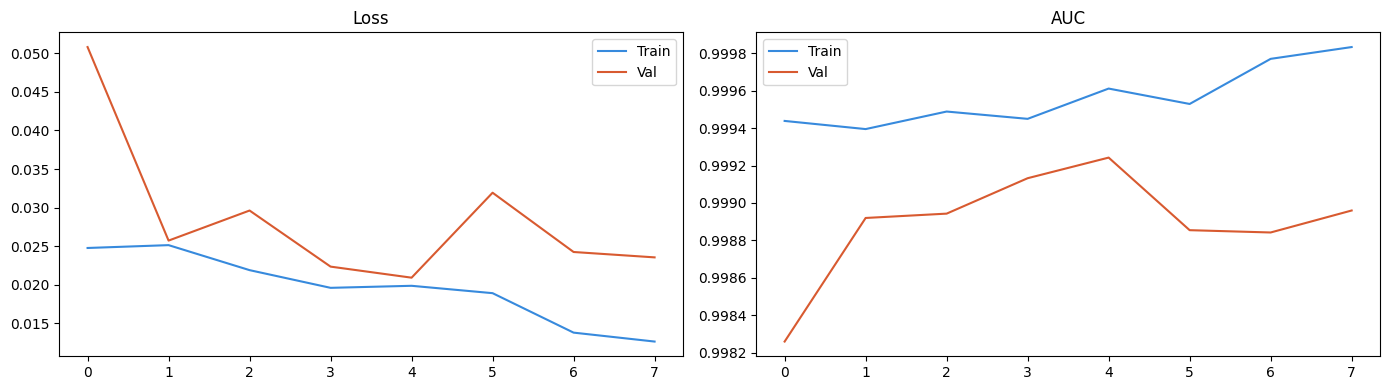

              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      4696
        REAL       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

AUC-ROC : 0.9996


In [ ]:
import matplotlib.pyplot as plt

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=3, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=128,
    callbacks=callbacks, verbose=1
)

# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in [
    (axes[0], 'loss',     'Loss'),
    (axes[1], 'auc',      'AUC')
]:
    ax.plot(history.history[metric],     label='Train', color='#378ADD')
    ax.plot(history.history[f'val_{metric}'], label='Val', color='#D85A30')
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/figures/lstm_learning_curves.png', dpi=150)
plt.show()

# Évaluation test
from sklearn.metrics import classification_report, f1_score, roc_auc_score
y_prob_lstm = model_lstm.predict(X_test, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)
print(classification_report(y_test, y_pred_lstm, target_names=['FAKE','REAL']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_lstm):.4f}")

sauvegarde LSTM + MLflow

In [ ]:
model_lstm.save(f'{BASE}/models/bilstm_model.h5')

import mlflow
mlflow.set_tracking_uri(f'{BASE}/mlruns')
mlflow.set_experiment("fake-news-detection")

with mlflow.start_run(run_name="BiLSTM_GloVe_Attention"):
    mlflow.log_params({"model":"BiLSTM", "embed":"GloVe100d",
                       "max_len":MAX_LEN, "lstm_units":"128-64"})
    mlflow.log_metrics({
        "f1_macro": f1_score(y_test, y_pred_lstm, average='macro'),
        "auc_roc" : roc_auc_score(y_test, y_prob_lstm)
    })

print(f"✓ BiLSTM sauvegardé — F1 macro : {f1_score(y_test, y_pred_lstm, average='macro'):.4f}")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


✓ BiLSTM sauvegardé — F1 macro : 0.9927


In [ ]:
import tensorflow as tf

class AttentionLayer(tf.keras.layers.Layer):
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(shape=(1,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, x):
        score   = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/FakeNewsProject'

import numpy as np
import pandas as pd
import os

# Charger données
test = pd.read_csv(f'{BASE}/data/processed/test.csv')
train = pd.read_csv(f'{BASE}/data/processed/train.csv')

# Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 400
VOCAB_SIZE = 60000

tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tok.fit_on_texts(train['clean_text'].fillna(''))

def encode(df):
    seqs = tok.texts_to_sequences(df['clean_text'].fillna(''))
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_test = encode(test)

# Charger modèle


from tensorflow.keras.models import load_model

model_lstm = load_model(
    f'{BASE}/models/bilstm_model.h5',
    custom_objects={'AttentionLayer': AttentionLayer},
    compile=False
)

# Prédictions
y_prob_lstm = model_lstm.predict(X_test, batch_size=128, verbose=1).flatten()

# Sauvegarde
os.makedirs(f'{BASE}/preds', exist_ok=True)
np.save(f'{BASE}/preds/lstm_probs.npy', y_prob_lstm)

print("✓ lstm_probs sauvegardé :", y_prob_lstm.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step
✓ lstm_probs sauvegardé : (8980,)
